# Belief State Geometry

Pretty fractals...

### Imports

In [32]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

import torch as t
from pca import load_pca_results, plot_in_simplex
from model import HookedTransformerModel

from hmm import Mess3Proc
from hmm_proc_kldiv import compute_log_likelihood_forward_conditional, compute_transformer_log_likelihood, generate_test_sequences

In [35]:
# Process entropy:
proc = Mess3Proc()
proc.entropy_rate_empirical_estimate(length=100000, burn_in=100)

0.7932891812676468

## Fractals

### The target

In [3]:
results = load_pca_results(save_dir="pca_results", run_id="20251207_232030")
metrics_df = results['metrics']
regressors = results['regressors']
data = results['data']  # Contains 'targets', 'layer_0_activations', 'layer_0_predictions', etc.
print(metrics_df)

Loaded metrics from pca_results/20251207_232030_metrics.csv
Loaded regressors from pca_results/20251207_232030_regressors.pkl
Loaded data from pca_results/20251207_232030_data.npz
  Available keys: ['targets', 'layer_0_activations', 'layer_0_predictions', 'layer_1_activations', 'layer_1_predictions', 'layer_2_activations', 'layer_2_predictions', 'layer_3_activations', 'layer_3_predictions']
   layer       mse  r2_score  baseline_mse
0      0  0.000666  0.995982      0.165787
1      1  0.000542  0.996731      0.165787
2      2  0.000410  0.997525      0.165787
3      3  0.000289  0.998258      0.165787


(<Figure size 1000x1000 with 1 Axes>, <Axes: title={'center': 'Targets'}>)

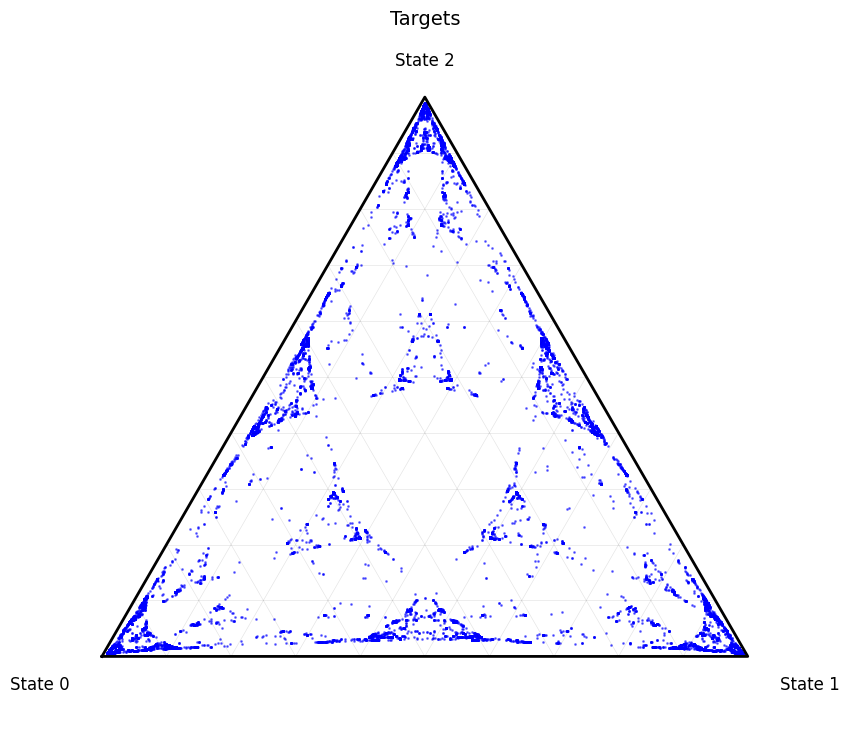

In [8]:
plot_in_simplex(data['targets'], title='Targets')

### Fractals evident in larger models

Reproduction of the paper: in larger, redundant architectual structure the fractal is more visible...

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': '3-Simplex Visualization'}>)

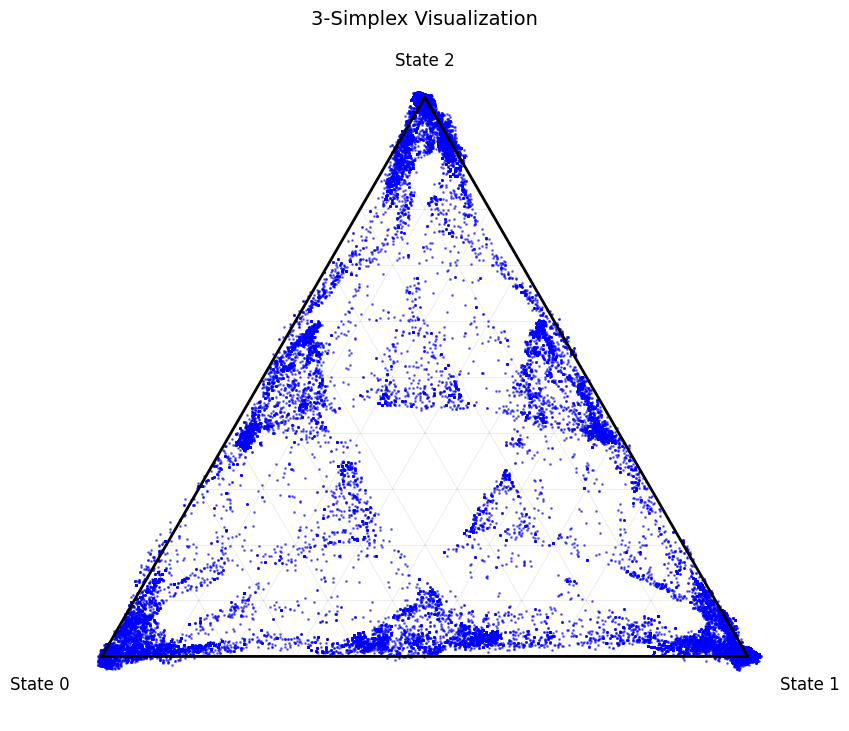

In [9]:
plot_in_simplex(data['layer_3_predictions'])

### Fractals not evident in simpler models

The attention-only, small models do not have well-represented belief state geometry

In [10]:
results = load_pca_results(save_dir="pca_results", run_id="20251127_134441")
metrics_df = results['metrics']
regressors = results['regressors']
data = results['data']  # Contains 'targets', 'layer_0_activations', 'layer_0_predictions', etc.
print(metrics_df)

Loaded metrics from pca_results/20251127_134441_metrics.csv
Loaded regressors from pca_results/20251127_134441_regressors.pkl
Loaded data from pca_results/20251127_134441_data.npz
  Available keys: ['targets', 'layer_0_activations', 'layer_0_predictions', 'layer_1_activations', 'layer_1_predictions']
   layer       mse  r2_score  baseline_mse
0      0  0.016376  0.901173      0.165708
1      1  0.010180  0.938579      0.165708


(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': '3-Simplex Visualization'}>)

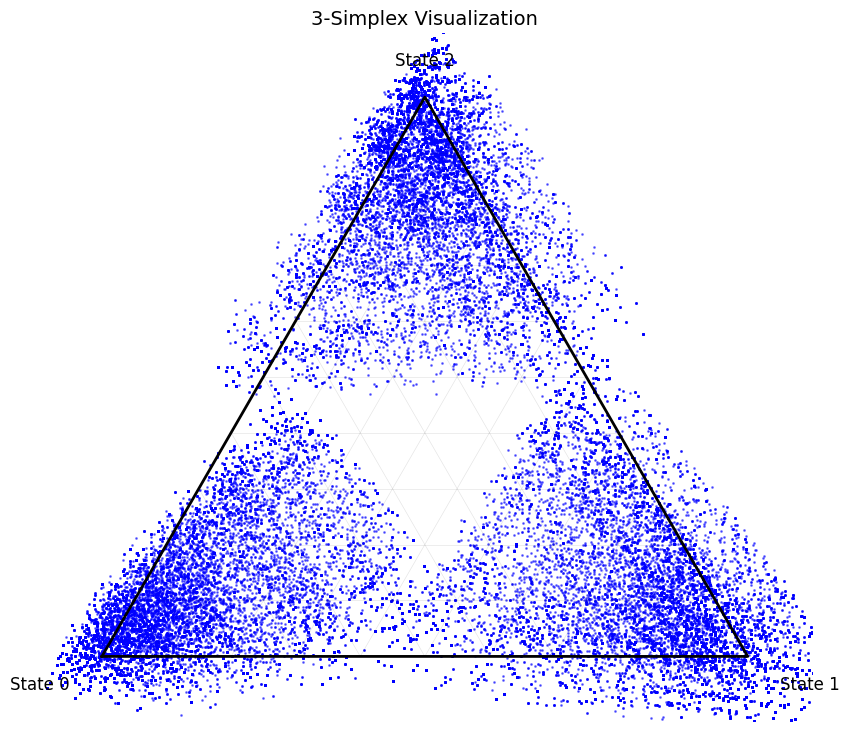

In [11]:
plot_in_simplex(data['layer_1_predictions'])

### Belief states of successful runs

In [3]:
import pandas as pd
metadata_path = 'records/metadata.parquet'
df = pd.read_parquet(metadata_path)
df_completed = df[df['status'] == 'completed']
print(df_completed.keys())
# len(df_completed)
selected_locs = [462, 426, 450, 13, 546] # Note this breaks down if you try to run again the metadata builder
df_selected = df_completed.loc[selected_locs]
print(df_selected[['final_val_loss', 'param_count', 'n_ctx']])
dirs = df_selected['run_dir'].tolist()

Index(['run_id', 'timestamp', 'uuid', 'run_dir', 'wandb_project',
       'wandb_run_name', 'is_sweep', 'status', 'has_config', 'has_metrics',
       'has_final_model', 'num_checkpoints', 'last_modified', 'model_name',
       'vocab_size', 'n_ctx', 'n_layer', 'n_embd', 'n_head', 'd_head',
       'n_inner', 'attn_only', 'normalization_type', 'activation_function',
       'param_count', 'process', 'batch_size', 'learning_rate', 'num_epochs',
       'device', 'scheduler_type', 'dataset_mode', 'final_loss',
       'final_val_loss', 'min_train_loss', 'min_val_loss', 'total_steps',
       'total_passes', 'final_lr', 'training_time_estimate', 'best_mean_r2',
       'best_layer_r2', 'final_llr_mean', 'final_llr_std',
       'validation_checkpoints', 'sweep_id', 'sweep_timestamp',
       'sweep_run_count', 'sweep_rank'],
      dtype='object')
     final_val_loss  param_count  n_ctx
462        0.798347       1232.0   15.0
426        0.800942       1128.0   10.0
450        0.804654       2352.0   

Loaded metrics from /mnt/users/clin/workspace/hidden-markov-chain/records/20251209_114642_7964018e/pca_metrics.csv
Loaded regressors from /mnt/users/clin/workspace/hidden-markov-chain/records/20251209_114642_7964018e/regressors.pkl
Loaded data from /mnt/users/clin/workspace/hidden-markov-chain/records/20251209_114642_7964018e/pca_data.npz
  Available keys: ['targets', 'layer_0_activations', 'layer_0_predictions', 'layer_1_activations', 'layer_1_predictions']
   layer       mse  r2_score  baseline_mse
0      0  0.002540  0.984708      0.166091
1      1  0.001054  0.993653      0.166091


(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': '3-Simplex Visualization'}>)

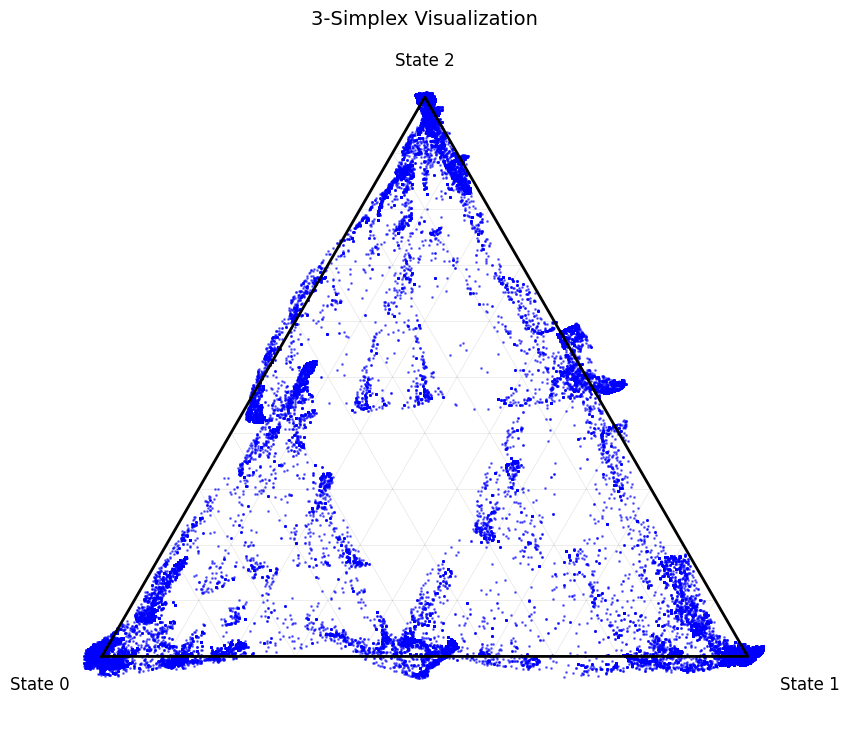

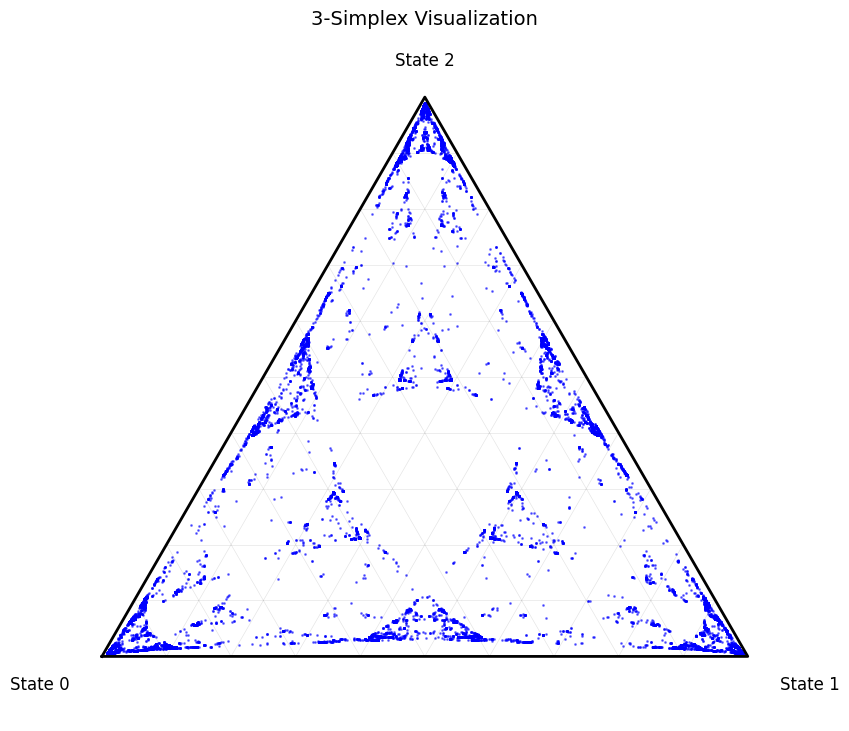

In [29]:
from pca import load_pca_results, plot_in_simplex
results = load_pca_results(save_dir=dirs[0], run_id=None)
# metrics_df = results['metrics']
# regressors = results['regressors']
data = results['data']  # Contains 'targets', 'layer_0_activations', 'layer_0_predictions', etc.
print(metrics_df)
plot_in_simplex(data['layer_1_predictions'])
plot_in_simplex(data['targets'])

## Evolution of MSP through training checkpoints

### Testing offset of LLR computation

The quantity being computed for the true log likelihood for offset $k$ is
$$
P(X_{k+1}, ..., X_{T-1} | X_0, X_1, ..., X_k)
$$

In [9]:
proc = Mess3Proc()
test_seq = t.tensor([[0, 0, 0]])
compute_log_likelihood_forward_conditional(proc, test_seq, offset=1)

array([-0.27995755])

In [ ]:
mess3_weight_paths = {
    4: 'records/20251127_122141',
    6: 'records/20251127_135107',
    8: 'records/20251127_135742',
    10: 'records/20251127_134441',
    15: 'records/20251127_135035',
}
cfg_paths = {key: os.path.join(value, 'config.yaml') for key, value in mess3_weight_paths.items()}
mdl_paths = {key: os.path.join(value, 'final_model_mess3.pt') for key, value in mess3_weight_paths.items()}
model = HookedTransformerModel(cfg_paths[4])
model.load_state_dict(t.load(mdl_paths[4], map_location='cpu'))
model.eval()

test_sequences = proc.generate_data(batch_size=1000, length=80)
llr_offset_test = compute_transformer_log_likelihood(model, test_sequences)
llr_true_test = compute_log_likelihood_forward_conditional(proc, test_sequences, offset=3)

print(llr_true_test.mean() - llr_offset_test.mean())

1.1234891800466187
